In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/dataset/first4.csv")

In [3]:
# Weighted Moving Average
def weighted_moving_average(series, window=5):
    weights = np.arange(1, window + 1)
    return series.rolling(window).apply(lambda x: np.dot(x, weights) / weights.sum(), raw=True)



In [4]:
'''try:
    df['hr_spline'] = df['heart_rate'].interpolate(method='cubic')
except Exception as e:
    print(f"Cubic spline error (likely memory or index): {e}")
    df['hr_spline'] = df['hr_linear'] # Fallback
'''

'try:\n    df[\'hr_spline\'] = df[\'heart_rate\'].interpolate(method=\'cubic\')\nexcept Exception as e:\n    print(f"Cubic spline error (likely memory or index): {e}")\n    df[\'hr_spline\'] = df[\'hr_linear\'] # Fallback\n'

In [5]:
df['hr_spline'] = df['heart_rate'].interpolate(method='cubic')

поособно

In [6]:
df['hr_weighted_avg'] = df.groupby('user_id')['heart_rate'].transform(weighted_moving_average)
print("Weighted moving average calculated per user_id.")

Weighted moving average calculated per user_id.


In [7]:
df['hr_spline'] = df.groupby('user_id')['heart_rate'].transform(lambda x: x.interpolate(method='cubic'))
print("Cubic spline interpolation calculated per user_id.")

Cubic spline interpolation calculated per user_id.


In [8]:
df['hr_linear'] = df.groupby('user_id')['heart_rate'].transform(lambda x: x.interpolate(method='linear'))
print("Linear interpolation calculated per user_id.")

Linear interpolation calculated per user_id.


In [124]:
print(df.count())

time_dt               5192696
time                  5192696
x                     5192696
y                     5192696
z                     5192696
heart_rate             948589
sleep_stage           4923090
user_id               5192696
hr_spline             4945096
hr_weighted_avg        879857
hr_linear             5191220
x_butter              5192696
x_moving_avg          5192692
y_butter              5192696
y_moving_avg          5192692
z_butter              5192696
z_moving_avg          5192692
movement              5192696
movement_std          5192695
hr_mean               5192696
hr_lag_5min            948580
mov_lag_5min          5192690
hr_lag_1s                 142
mov_lag_1s            5192695
hr_lag_5min_norm      5192696
mov_lag_5min_norm     5192696
rmssd                 5132033
hr_min_1h             5192597
circadian_distance    5191121
is_rem                5192696
N1_2                  5192696
to_wake               5192696
dtype: int64


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5193000 entries, 0 to 5192999
Data columns (total 10 columns):
 #   Column           Dtype  
---  ------           -----  
 0   time             float64
 1   x                float64
 2   y                float64
 3   z                float64
 4   heart_rate       float64
 5   sleep_stage      float64
 6   user_id          int64  
 7   hr_spline        float64
 8   hr_weighted_avg  float64
 9   hr_linear        float64
dtypes: float64(9), int64(1)
memory usage: 396.2 MB


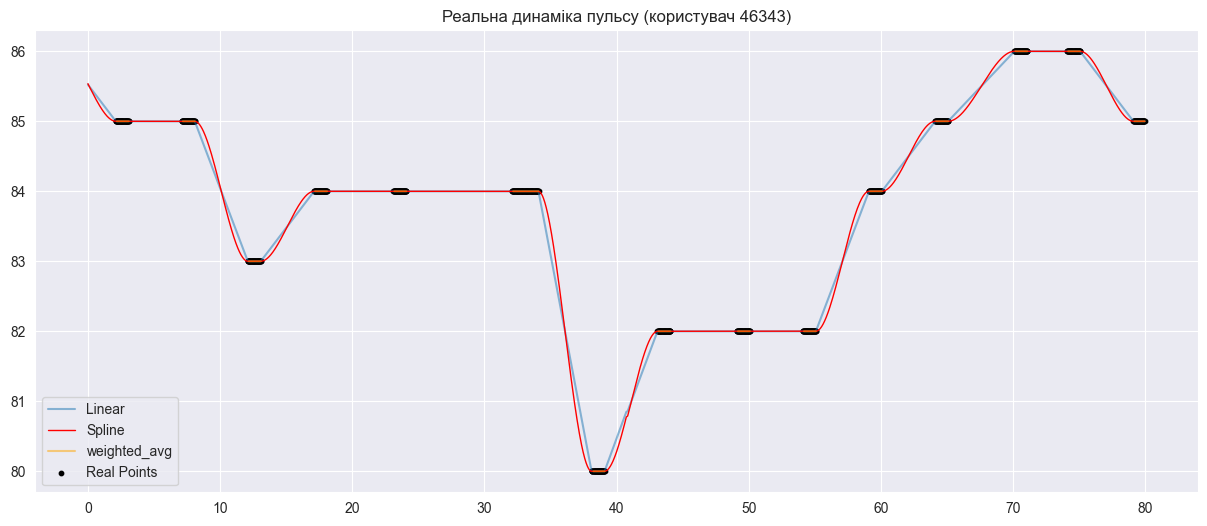

In [10]:
target_user = 46343
user_data = df[df['user_id'] == target_user]

# 5000 рядків ~2.5 хвилини
sample_size = 4000
start_idx = len(user_data) // 2
user_sample = user_data.iloc[start_idx : start_idx + sample_size].copy()

# Обчислимо відносний час
user_sample['time_rel'] = user_sample['time'] - user_sample['time'].iloc[0]

plt.figure(figsize=(15, 6))
plt.plot(user_sample['time_rel'], user_sample['hr_linear'], label='Linear', alpha=0.5)
plt.plot(user_sample['time_rel'], user_sample['hr_spline'], label='Spline', color='red', linewidth=1)
plt.plot(user_sample['time_rel'], user_sample['hr_weighted_avg'], label='weighted_avg', color='orange', alpha=0.5)
plt.scatter(user_sample['time_rel'], user_sample['heart_rate'], color='black', s=10, label='Real Points')


plt.title(f"Реальна динаміка пульсу (користувач {target_user})")
plt.legend()
plt.show()

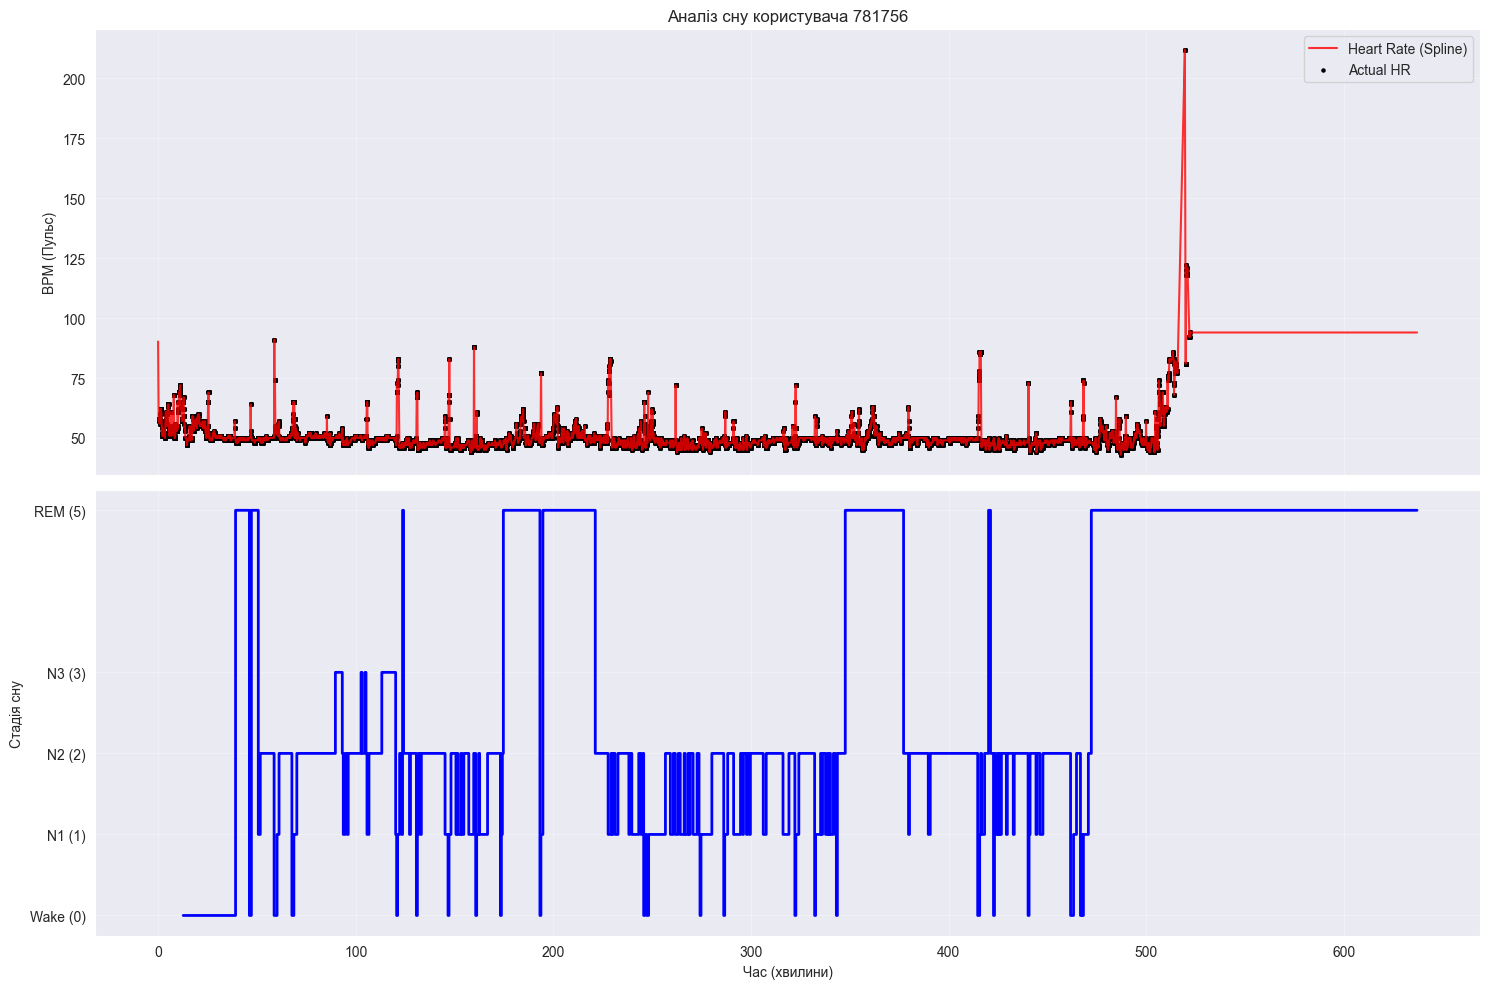

In [28]:
sample_size = 2000000000
start_idx = 2000
target_user = 781756
user_sample = df[df['user_id'] == target_user].iloc[start_idx : start_idx + sample_size].copy()

# Відносний час у хвилинах
user_sample['time_min'] = (user_sample['time'] - user_sample['time'].iloc[0]) / 60

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

ax1.plot(user_sample['time_min'], user_sample['hr_linear'], color='red', label='Heart Rate (Spline)', alpha=0.8)
ax1.scatter(user_sample['time_min'], user_sample['heart_rate'], color='black', s=5, label='Actual HR')
ax1.set_ylabel('BPM (Пульс)')
ax1.set_title(f'Аналіз сну користувача {target_user}')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)


ax2.step(user_sample['time_min'], user_sample['sleep_stage'], where='post', color='blue', linewidth=2, label='Sleep Stage')


ax2.set_yticks([0, 1, 2, 3, 5])
ax2.set_yticklabels(['Wake (0)', 'N1 (1)', 'N2 (2)', 'N3 (3)', 'REM (5)' ])
ax2.set_ylabel('Стадія сну')
ax2.set_xlabel('Час (хвилини)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [110]:
from scipy.signal import medfilt, butter, filtfilt

In [112]:
#  Параметри Баттерворта
fs = 50  # частота (Гц)
lowcut = 2.0
b, a = butter(4, lowcut/(0.5*fs), btype='low')

# Параметри Ковзного середнього
window_size = 5

axes = ['x', 'y', 'z']
for ax in axes:
    # Баттерворт
    df[f'{ax}_butter'] = filtfilt(b, a, df[ax])
    # Ковзне середнє
    df[f'{ax}_moving_avg'] = df[ax].rolling(window=window_size, center=True).mean()

print("Прості фільтри застосовано.")

Прості фільтри застосовано.


In [62]:
#df= df[df['sleep_stage'].notna()]

похбка епл вотча
+- 0.01g до +- 0.05g
g = 9,80665

In [128]:
g = 9.80665

In [114]:
df['movement'] = np.sqrt(df['x_butter']**2 + df['y_butter']**2 + df['z_butter']**2) * g

In [20]:
df

,time,x,y,z,heart_rate,sleep_stage,user_id,hr_spline,hr_weighted_avg,hr_linear,x_butter,x_moving_avg,y_butter,y_moving_avg,z_butter,z_moving_avg,movement
0,-25277.015599,-0.050598,-0.493759,-0.864624,NaN,NaN,759667,NaN,NaN,NaN,-0.047247,NaN,-0.494962,NaN,-0.858026,NaN,9.725049
1,-25276.988283,-0.046646,-0.564392,-0.896088,NaN,NaN,759667,NaN,NaN,NaN,-0.037072,NaN,-0.510210,NaN,-0.850747,NaN,9.735085
2,-25276.987249,-0.023285,-0.521210,-0.876205,NaN,NaN,759667,NaN,NaN,NaN,-0.027326,-0.018246,-0.525718,-0.534848,-0.843435,-0.883789,9.750138
3,-25276.984253,0.000168,-0.540863,-0.900650,NaN,NaN,759667,NaN,NaN,NaN,-0.018599,-0.004028,-0.540980,-0.545908,-0.836107,-0.882178,9.767740
4,-25276.964378,0.029129,-0.554016,-0.881378,NaN,NaN,759667,NaN,NaN,NaN,-0.011460,0.007404,-0.555433,-0.539996,-0.828844,-0.872562,9.785143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5192995,28828.068306,0.509995,0.462479,-0.559250,NaN,-1.0,844359,NaN,NaN,85.0,0.501216,0.454742,0.505365,0.516144,-0.723331,-0.576584,9.951787
5192996,28828.089226,0.465301,0.612167,-0.612411,NaN,-1.0,844359,NaN,NaN,85.0,0.511281,0.475174,0.557809,0.548846,-0.729316,-0.637961,10.306137
5192997,28828.109608,0.429871,0.622650,-0.694794,NaN,-1.0,844359,NaN,NaN,85.0,0.523477,0.495801,0.610410,0.603635,-0.738399,-0.692664,10.706153
5192998,28828.128373,0.506653,0.607361,-0.815720,NaN,-1.0,844359,NaN,NaN,85.0,0.537179,NaN,0.661871,NaN,-0.750015,NaN,11.134573


In [115]:

df['timestamp'] = pd.to_datetime(df['time'])


df = df.set_index('timestamp').sort_index()

df['movement_std'] = df['movement'].rolling(window='6s').std()
df['hr_mean'] = df['heart_rate'].rolling(window='6s').mean()

In [116]:
df['hr_lag_5min'] = df['heart_rate'].shift(5)

df['mov_lag_5min'] = df['movement_std'].shift(5)

In [117]:
# 1. Перетворюємо в Timedelta
df['time_dt'] = pd.to_timedelta(df['time'], unit='s')

# 2. Видаляємо дублікати за часом (залишаємо тільки перший запис для кожної мілісекунди)
df = df.drop_duplicates(subset=['time_dt'])

# 3. Встановлюємо індекс
df = df.set_index('time_dt')

# 4. Тепер shift спрацює без помилок
df['hr_lag_1s'] = df['heart_rate'].shift(periods=1, freq='2s')

# 5. Для rolling теж важливо, щоб індекс був відсортований
df = df.sort_index()
df['mov_lag_1s'] = df['movement_std'].rolling(window='2s').mean()

df = df.reset_index()

In [118]:
# нормалізація
cols_to_norm = ['hr_lag_5min', 'mov_lag_5min']


for col in cols_to_norm:
    col_min = df[col].min()
    col_max = df[col].max()
    # Формула: (x - min) / (max - min)
    df[col + '_norm'] = (df[col] - col_min) / (col_max - col_min)

df[['hr_lag_5min_norm', 'mov_lag_5min_norm']] = df[['hr_lag_5min_norm', 'mov_lag_5min_norm']].fillna(0)

In [137]:
# Розрахунок RMSSD (Варіабельність пульсу)
df['hr_diff_sq'] = df['hr_linear'].diff()**2

# Потім беремо середнє від цих квадратів у вікні та добуваємо корінь
window_5min = 21000
df['rmssd'] = np.sqrt(df['hr_diff_sq'].rolling(window=window_5min).mean())

# Circadian Distance (Наскільки пульс вищий за мінімум за годину)
# 1 година = 3600 секунд * 70 рядків = 252000 рядків
window_1h = 252000
df['hr_min_1h'] = df['hr_linear'].rolling(window=window_1h, min_periods=100).min()
df['circadian_distance'] = df['hr_linear'] - df['hr_min_1h']

# REM зазвичай характеризується низьким рухом та високою варіабельністю пульсу
# Це спрощена логіка для аналізу, модель потім сама уточнить ваги
df['is_rem'] = ((df['sleep_stage'] == 'REM') | (df['sleep_stage'] == 5)).astype(int)


df['N1_2'] = df['sleep_stage'].isin(['N1', 'N2', 1, 2]).astype(int)

# Очищення тимчасових колонок
df.drop(columns=['hr_diff_sq'], inplace=True)

In [125]:
df['to_wake'] = ((df['sleep_stage'] == 0) | (df['sleep_stage'] == 1) | (df['sleep_stage'] == 2)).astype(int)

In [121]:
import seaborn as sns

In [27]:
#srach
'''
    'hr_spline',
    'hr_weighted_avg',
'''

"\n    'hr_spline',\n    'hr_weighted_avg',\n"

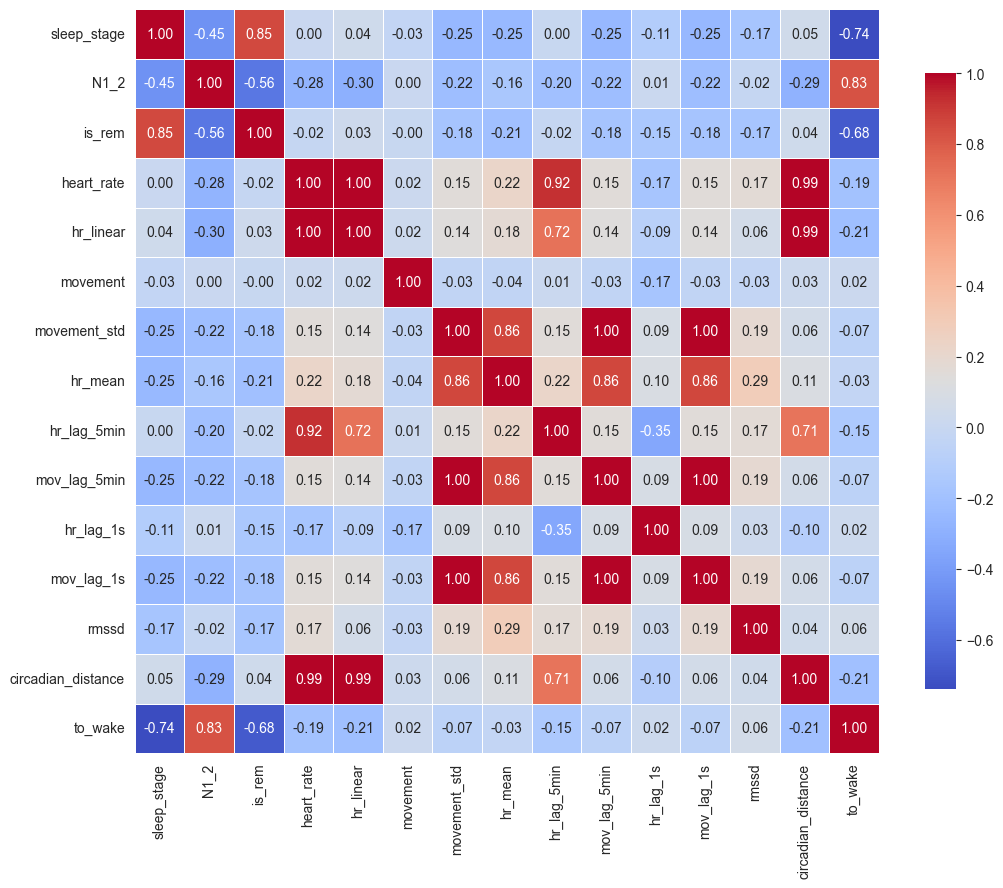

In [156]:
df1= df[df['sleep_stage'].notna()]

columns_to_show = [
    'sleep_stage',
    'N1_2',
    'is_rem',
    'heart_rate',
    'hr_linear',
    'movement',
    'movement_std',
    'hr_mean',
    'hr_lag_5min',
    'mov_lag_5min',
    'hr_lag_1s',
    'mov_lag_1s',
    'rmssd',
    'circadian_distance',
    'to_wake'
]

existing_columns = [col for col in columns_to_show if col in df.columns]
correlation_df = df1[existing_columns]

correlation_matrix = correlation_df.corr()


plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": .8}
)

plt.show()

In [127]:
df1 = df[
    (df['movement_std'].notna()) &
    (df['hr_mean'].notna()) &
    (df['rmssd'].notna()) &
    (df['circadian_distance'].notna()) &
    (df['sleep_stage'].notna())
].copy()

In [77]:
features = ['movement_std', 'hr_mean', 'rmssd', 'circadian_distance']
label = "to_wake"

In [129]:
df2 = df1[list(features) + [label]]

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [80]:
from sklearn.metrics import accuracy_score, classification_report

In [130]:
X_data = df2[list(features)]
Y_data = df2[label]

X_train, X_test, y_train, y_test = train_test_split(X_data, Y_data, test_size=0.2, random_state=42)

In [131]:
scaler = StandardScaler()
scaler

StandardScaler()

In [132]:
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (3938472, 4)
X_test_scaled shape: (984618, 4)


In [133]:
X_data = df2[list(features)]
Y_data = df2[label]

X_train, X_test, Y_train, Y_test = train_test_split(X_data, Y_data, test_size=0.2, random_state=42)


#scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

#для їх датасету
#X_train_scaled = X_train
#X_test_scaled = X_test

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (3938472, 4)
X_test_scaled shape: (984618, 4)


In [134]:
random_forest_model = RandomForestClassifier(random_state=42)
random_forest_model.fit(X_train_scaled, Y_train)

RandomForestClassifier(random_state=42)

In [135]:
Y_pred_rf = random_forest_model.predict(X_test_scaled)

accuracy_rf = accuracy_score(Y_test, Y_pred_rf)

print(f'RandomForestClassifier Accuracy: {accuracy_rf:.4f}')
print('\nClassification Report for RandomForestClassifier:')
print(classification_report(Y_test, Y_pred_rf))


RandomForestClassifier Accuracy: 0.9997

Classification Report for RandomForestClassifier:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    399546
           1       1.00      1.00      1.00    585072

    accuracy                           1.00    984618
   macro avg       1.00      1.00      1.00    984618
weighted avg       1.00      1.00      1.00    984618



In [ ]:
n_estimators_range = range(5, 25)
accuracy_rf_estimators = []

for n_estimators in n_estimators_range:
    rf_model = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
    rf_model.fit(X_train_scaled, Y_train)
    Y_pred_rf = rf_model.predict(X_test_scaled)
    accuracy = accuracy_score(Y_test, Y_pred_rf)
    accuracy_rf_estimators.append(accuracy)

print("RandomForest Accuracy for different number of estimators (1-5):")
for i in range(len(n_estimators_range)):
    print(f"n_estimators={n_estimators_range[i]}: Accuracy={accuracy_rf_estimators[i]:.4f}")

новий користувач

In [148]:
df_test = pd.read_csv("../data/dataset/8173033.csv")

In [38]:
try:
    # For very large datasets like yours (51M rows), spline might be slow.
    # We limit the limit_direction to fill all gaps.
    df_test['hr_spline'] = df_test['heart_rate'].interpolate(method='cubic')
except Exception as e:
    print(f"Cubic spline error (likely memory or index): {e}")
    df_test['hr_spline'] = df_test['hr_linear'] # Fallback


In [149]:
df_test['hr_spline'] = df_test['heart_rate'].interpolate(method='cubic')

In [150]:
axes = ['x', 'y', 'z']
for ax in axes:
    # Fill NaNs in the raw accelerometer data with 0 before filtering
    df_test[ax] = df_test[ax].fillna(0)
    # Баттерворт
    df_test[f'{ax}_butter'] = filtfilt(b, a, df_test[ax])
    # Ковзне середнє
    df_test[f'{ax}_moving_avg'] = df_test[ax].rolling(window=window_size, center=True).mean()

In [151]:
df_test['movement'] = np.sqrt(df_test['x_butter']**2 + df_test['y_butter']**2 + df_test['z_butter']**2) * g

In [152]:
# Перетворюємо час у формат timedelta
df_test['time_dt'] = pd.to_timedelta(df_test['time'], unit='s')

df_test = df_test.drop_duplicates(subset=['time_dt'])

df_test = df_test.set_index('time_dt').sort_index()


df_test['movement_std'] = df_test['movement'].rolling(window='6s').std()
df_test['hr_mean'] = df_test['heart_rate'].rolling(window='6s').mean()

In [153]:
#  RMSSD (Варіабельність пульсу)
df_test['hr_diff_sq'] = df_test['hr_spline'].diff()**2


#  5 хвилин ~ 300 секунд
window_5min = 21000
df_test['rmssd'] = np.sqrt(df_test['hr_diff_sq'].rolling(window=window_5min).mean())

In [154]:
window_1h = 252000
df_test['hr_min_1h'] = df_test['hr_spline'].rolling(window=window_1h, min_periods=100).min()
df_test['circadian_distance'] = df_test['hr_spline'] - df_test['hr_min_1h']

In [155]:
df_test['to_wake'] = ((df_test['sleep_stage'] == 0) | (df_test['sleep_stage'] == 1) | (df_test['sleep_stage'] == 2)).astype(int)

In [157]:
df_test

,time,x,y,z,heart_rate,sleep_stage,user_id,hr_spline,x_butter,x_moving_avg,...,z_butter,z_moving_avg,movement,movement_std,hr_mean,hr_diff_sq,rmssd,hr_min_1h,circadian_distance,to_wake
time_dt,,,,,,,,,,,,,,,,,,,,,
-1 days +17:28:37.536559100,-23482.463441,0.036377,0.005478,-0.999588,NaN,NaN,8173033,NaN,0.036378,NaN,...,-0.999632,NaN,9.809679,NaN,NaN,NaN,NaN,NaN,NaN,0
-1 days +17:28:37.572702900,-23482.427297,0.035904,0.005966,-1.000076,NaN,NaN,8173033,NaN,0.036408,NaN,...,-0.999799,NaN,9.811322,0.001162,NaN,NaN,NaN,NaN,NaN,0
-1 days +17:28:37.573112,-23482.426888,0.036880,0.006943,-1.000061,NaN,NaN,8173033,NaN,0.036441,0.036398,...,-0.999960,-1.000458,9.812917,0.001619,NaN,NaN,NaN,NaN,NaN,0
-1 days +17:28:37.573499,-23482.426501,0.036423,0.005966,-1.001526,NaN,NaN,8173033,NaN,0.036478,0.036594,...,-1.000112,-1.000452,9.814423,0.002044,NaN,NaN,NaN,NaN,NaN,0
-1 days +17:28:37.589081,-23482.410919,0.036408,0.004990,-1.001038,NaN,NaN,8173033,NaN,0.036517,0.036401,...,-1.000251,-1.000650,9.815806,0.002430,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0 days 06:07:01.133802900,22021.133803,-0.470795,-0.035706,-0.885742,NaN,5.0,8173033,NaN,-0.465129,-0.467862,...,-0.493944,-0.885880,6.664709,0.292521,77.0,NaN,NaN,55.0,NaN,0
0 days 06:07:01.153380900,22021.153381,-0.468369,-0.035690,-0.885208,NaN,5.0,8173033,NaN,-0.464532,-0.466870,...,-0.379870,-0.886539,5.897449,0.369728,77.0,NaN,NaN,55.0,NaN,0
0 days 06:07:01.173228,22021.173228,-0.464447,-0.037643,-0.885620,NaN,5.0,8173033,NaN,-0.463902,-0.465500,...,-0.260745,-0.709201,5.233155,0.454141,77.0,NaN,NaN,55.0,NaN,0


In [158]:
df2_test = df_test[
    (df_test['movement_std'].notna()) &
    (df_test['hr_mean'].notna()) &
    (df_test['rmssd'].notna()) &
    (df_test['circadian_distance'].notna()) &
    (df_test['sleep_stage'].notna())
].copy()

In [160]:
X_test_new = df2_test[features]
y_test_new = df2_test[label]

X_test_new_scaled = scaler.transform(X_test_new)

Y_pred_rf_new = random_forest_model.predict(X_test_new_scaled)

accuracy_rf_new = accuracy_score(y_test_new, Y_pred_rf_new)

print(f'RandomForestClassifier Accuracy on new test data: {accuracy_rf_new:.4f}')
print('\nClassification Report for RandomForestClassifier on new test data:')
print(classification_report(y_test_new, Y_pred_rf_new))

RandomForestClassifier Accuracy on new test data: 0.3575

Classification Report for RandomForestClassifier on new test data:
              precision    recall  f1-score   support

           0       0.36      0.66      0.47    442085
           1       0.35      0.13      0.19    603016

    accuracy                           0.36   1045101
   macro avg       0.36      0.40      0.33   1045101
weighted avg       0.35      0.36      0.31   1045101



труба(